<a href="https://colab.research.google.com/github/monasolgi/Computer_vision/blob/main/tutorial3_CV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#for one single sample
import numpy as np

def f_org(x):
  return (1/(1+np.exp(-10*x**2)))-1/2
k=2
X=np.random.normal(0,1,size=(1,1))
Y=f_org(X)+X

#print(X,Y)

W_1=np.random.normal(size=(k,1))
b_1=np.random.normal(size=(k,1))
W_2=np.random.normal(size=(1,k))
b_2=np.random.normal(size=(1,1))

def sigmoid(x):
  return 1/(1+np.exp(-x))
def forward_prop(X,W_1,b_1,W_2,b_2):
  Z = W_1 @ X + b_1
  h=sigmoid(Z)
  y_hat = W_2 @ h + b_2
  loss=(y_hat-Y)**2
  return y_hat,h,loss

#print(loss)
#print(y_hat,Y)
print(W_1,W_2,b_1,b_2)
learning_rate=0.01
loss=[]
for i in range(100):
  y_hat,h,loss=forward_prop(X,W_1,b_1,W_2,b_2)
  dl=2*(y_hat-Y)
  dw_2=dl * np.transpose(h)
  db_2=dl
  dw_1=dl * np.transpose(W_2) * h*(1-h) * X
  db_1=dl * np.transpose(W_2) * h*(1-h)

  W_1=W_1-learning_rate*dw_1
  b_1=b_1-learning_rate*db_1
  W_2=W_2-learning_rate*dw_2
  b_2=b_2-learning_rate*db_2

  if np.sqrt(np.sum(dw_1**2)+np.sum(db_1**2)+np.sum(dw_2**2)+np.sum(db_2**2))<0.001:
    break


print(W_1,W_2,b_1,b_2)

[[-0.00230778]
 [ 0.3194246 ]] [[ 0.4126158  -1.57970357]] [[0.13402854]
 [0.35554639]] [-0.35058408]
[[0.06090134]
 [0.19971358]] [[ 0.95727806 -1.01612036]] [[0.2982168 ]
 [0.04459215]] [[0.63419181]]


X_training → Y_noisy → training

X_test → prediction only

Y_clean_test → comparison

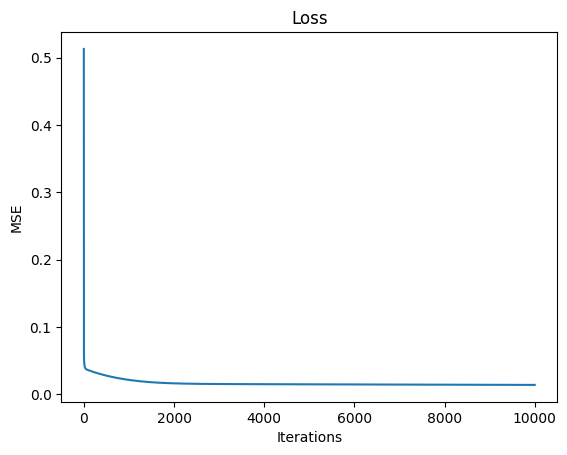

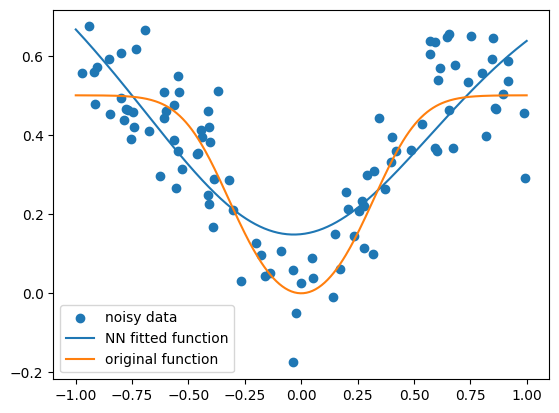

In [28]:
#for multiple samples
import numpy as np

k=10#number of hidden neurons
N=100
s=0.1

#random.rand create values [0,1] then *2 makes it [0,2]
#since we want it from -1 to 1 we subtract -1
X_training = 2 * np.random.rand(1,N) - 1

#create training labels with noise
Y_clean_training=(1/(1+np.exp(-10* X_training **2)))- 0.5
Y_noisy=Y_clean_training + s * np.random.normal(0, 1, size=(1,N))

W_1=np.random.normal(size=(k,1))
b_1=np.random.normal(size=(k,1))
W_2=np.random.normal(size=(1,k))
b_2=np.random.normal(size=(1,1))

def sigmoid(x):
  return 1/(1+np.exp(-x))


def forward_prop(X,W_1,b_1,W_2,b_2):
  Z = W_1 @ X + b_1
  h=sigmoid(Z)
  y_hat = W_2 @ h + b_2
  return y_hat,h

learning_rate=0.05
loss_list=[]

X_test=np.linspace(-1,1,300).reshape(1,-1)# to reshape (300,) into (1,300)
Y_clan_test=(1/(1+np.exp(-10* X_test **2)))- 0.5

#trianing
for i in range(10000):
  y_hat,h=forward_prop(X_training,W_1,b_1,W_2,b_2)
  loss=np.mean((y_hat-Y_noisy)**2)
  loss_list.append(loss)

  #gradient
  dl=2*(y_hat- Y_noisy) / N #(1,N)
  dw_2=dl @ np.transpose(h) #(1,N) @ (N,K)
  db_2=np.sum(dl,axis=1,keepdims=True) #(1,1)
  dz=(np.transpose(W_2)@dl) * h * (1-h) #(k,N)
  dw_1=dz @ X_training.T #(K,N) @ (N,1)=(k,1)
  db_1=np.sum(dz,axis=1,keepdims=True) #(K,1)

  #update
  W_1=W_1-learning_rate*dw_1
  b_1=b_1-learning_rate*db_1
  W_2=W_2-learning_rate*dw_2
  b_2=b_2-learning_rate*db_2

  if np.sqrt(np.sum(dw_1**2)+np.sum(db_1**2)+np.sum(dw_2**2)+np.sum(db_2**2))<0.001:
    break

#testing
y_test,_=forward_prop(X_test,W_1,b_1,W_2,b_2)

import matplotlib.pyplot as plt
plt.plot(loss_list)
plt.title("Loss")
plt.xlabel("Iterations")
plt.ylabel("MSE")
plt.show()

plt.scatter(X_training.flatten(),Y_noisy.flatten(),label="noisy data")
plt.plot(X_test.flatten(),y_test.flatten(),label="NN fitted function")
plt.plot(X_test.flatten(),Y_clan_test.flatten(),label="original function")
plt.legend()
plt.show()

0 0.8772820830345154


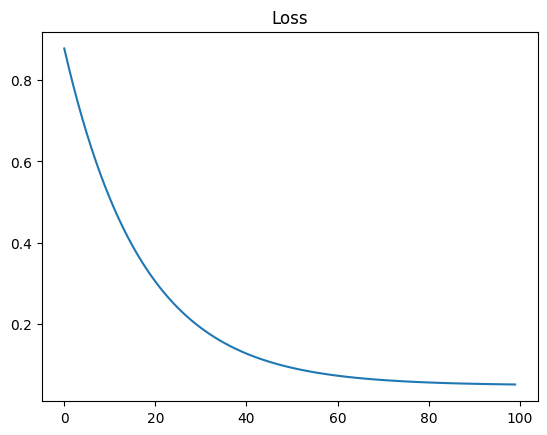

In [8]:
#Implementing autodiff
import torch
import torch.nn as nn

N=100
k=2
s=0.1
X = 2 * torch.rand(N,1) - 1
Y=(1/(1+torch.exp(-10* X **2)))- 0.5 + s*torch.randn(N,1)

model=nn.Sequential(
    nn.Linear(1,k),
    nn.Sigmoid(),
    nn.Linear(k,1)
)
loss_fn=nn.MSELoss()
optimizer=torch.optim.SGD(model.parameters(),lr=0.01)

loss_list=[]
for i in range(100):
  y_hat=model(X)
  loss=loss_fn(y_hat,Y)
  loss_list.append(loss.item())
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  if i % 100 ==0:
    print(i,loss.item())

import matplotlib.pyplot as plt
plt.plot(loss_list)
plt.title("Loss")
plt.show()

